# 00 · EDA y preparación de datos — Caso de uso 5 (Segmentación)

**Metodología:** CRISP-DM · Fases 2–3 · **Proyecto:** ACH Data · ACH Colombia

Este notebook prepara y entiende los datos para los modelos de clustering. Cubre cuatro decisiones de
preparación y un EDA por dataset con transformación:

1. **Identidad → llave por cédula** (y el riesgo que asumimos).
2. **Cruce entre fuentes** por cédula (¿cuántos clientes en cada combinación?).
3. **Deduplicación** y **cuenta propia** (transferencias internas que NO son ingreso).
4. **Categorización por dataset**: clasificación de personas en Seguridad Social (empleado, independiente,
   pensionado…), consumo en PSE, flujos en Transferencias.

La lógica reutilizable vive en `scripts/ach_pipeline.py`; aquí se documenta, valida y materializa.

## 0 · Configuración

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
import ach_pipeline as ap   # noqa: E402

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (11, 4.2),
                     "axes.titlesize": 12, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 40)
milM = mticker.FuncFormatter(lambda x, _: f"${x/1e6:,.1f}M")
print("Listo · pandas", pd.__version__)

Listo · pandas 2.3.3


## 1 · Decisión de identidad: llave por CÉDULA

El `Número documento` llega enmascarado **idéntico en las 3 fuentes** (primeros 8 dígitos + `****`), así que
sirve como llave para cruzarlas directamente. Tiene un costo: una cédula enmascarada puede cubrir a más de una
persona real (se ocultan 4 dígitos). Lo medimos usando el nombre visible de SS como proxy de identidad.

In [2]:
rep = ap.collision_report(ap.load_raw("ss"), "ss")
print("Cédulas enmascaradas únicas (SS)         :", f"{rep['llaves_solo_doc']:,}")
print("... que cubren >1 persona (colisión)      :", f"{rep['colision_solo_doc_%']}%")
print("Máx. personas bajo una misma cédula        :", rep["max_personas_por_llave_doc"])

Cédulas enmascaradas únicas (SS)         : 33,281
... que cubren >1 persona (colisión)      : 12.99%
Máx. personas bajo una misma cédula        : 13


> **Riesgo asumido (decisión de negocio):** se cruza **solo por cédula**. Asumimos que la probabilidad de que
> una cédula enmascarada mezcle a personas distintas es **baja y afecta a pocos clientes**, y aceptamos ese
> riesgo a cambio de poder **cruzar las tres fuentes** y enriquecer los modelos. (La ~13% medida es un límite
> superior calculado sobre el nombre ofuscado; el impacto real en el modelado es menor y se resuelve
> definitivamente cuando ACH entregue la llave hasheada consistente.)

## 2 · Cruce entre fuentes por cédula

¿Cuántos clientes hay en cada combinación de fuentes? Primero **Transferencias ∩ PSE** (las dos fuentes
transaccionales), luego las tres.

In [3]:
docs = {f: set(ap.add_person_key(ap.load_raw(f).drop_duplicates(), f)["person_id"].dropna())
        for f in ["ss", "trf", "pse"]}
ss, trf, pse = docs["ss"], docs["trf"], docs["pse"]
universo = ss | trf | pse

combos = {
    "Solo Seguridad Social": len(ss - trf - pse),
    "Solo Transferencias":   len(trf - ss - pse),
    "Solo PSE":              len(pse - ss - trf),
    "Transferencias ∩ PSE":  len((trf & pse) - ss),
    "SS ∩ Transferencias":   len((ss & trf) - pse),
    "SS ∩ PSE":              len((ss & pse) - trf),
    "Las 3 fuentes":         len(ss & trf & pse),
}
tabla = pd.DataFrame({"clientes": combos})
tabla["%_universo"] = (tabla["clientes"] / len(universo) * 100).round(1)
display(tabla)
print(f"Transferencias ∩ PSE (núcleo del modelo de valor): {len(trf & pse):,}")
print(f"Las 3 fuentes (base del modelo de ciclo de vida) : {len(ss & trf & pse):,}")
print(f"Universo total de clientes (unión)               : {len(universo):,}")

,clientes,%_universo
Solo Seguridad Social,8728,21.3
Solo Transferencias,695,1.7
Solo PSE,639,1.6
Transferencias ∩ PSE,6277,15.4
SS ∩ Transferencias,1613,3.9
SS ∩ PSE,4621,11.3
Las 3 fuentes,18319,44.8


Transferencias ∩ PSE (núcleo del modelo de valor): 24,596
Las 3 fuentes (base del modelo de ciclo de vida) : 18,319
Universo total de clientes (unión)               : 40,892


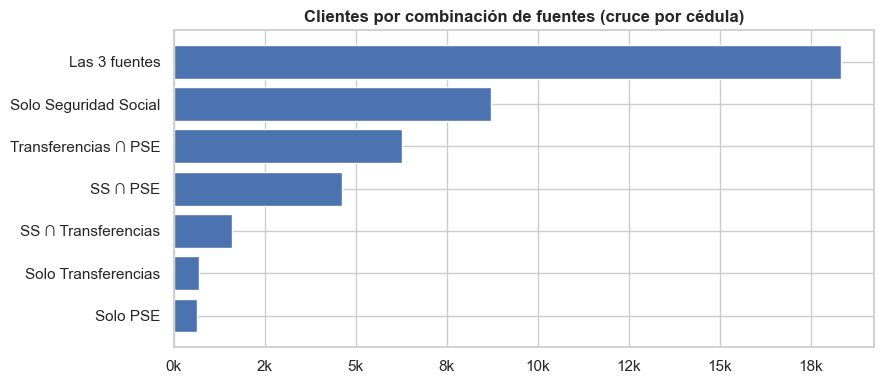

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
s = pd.Series(combos).sort_values()
ax.barh(s.index, s.values, color="#4c72b0")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f}k"))
ax.set_title("Clientes por combinación de fuentes (cruce por cédula)")
plt.tight_layout(); plt.show()

## 3 · Deduplicación y cuenta propia

**Duplicados exactos:** marginales (se eliminan igual). Lo que se repite masivamente son las columnas de
*resumen por persona* replicadas en cada fila — eso es diseño del extracto, no duplicación de hechos.

In [5]:
for f in ["ss", "trf", "pse"]:
    df = ap.load_raw(f)
    print(f"  {f.upper():4}: {df.duplicated().sum():,} filas duplicadas exactas de {len(df):,} "
          f"({df.duplicated().mean()*100:.2f}%)")

  SS  : 50 filas duplicadas exactas de 743,406 (0.01%)


  TRF : 7,291 filas duplicadas exactas de 1,048,574 (0.70%)


  PSE : 1 filas duplicadas exactas de 1,048,574 (0.00%)


**Cuenta propia (crítico):** ~19% de las transferencias son entre cuentas de la **misma persona**. Ese dinero
**no es ingreso ni gasto** — es un movimiento interno. Si se contara como "recibido", inflaría el ingreso. Por
eso `recibido`/`enviado` en las tablas persona×mes **excluyen** cuenta propia; el movimiento interno se guarda
aparte (`cuenta_propia_total`).

In [6]:
trf_raw = ap.load_raw("trf")
cp = trf_raw["Cuenta propia"].astype("string").str.upper().value_counts(dropna=False)
print("Transferencias por 'Cuenta propia':")
print(cp.to_string())
print(f"\n-> {cp.get('SI',0)/cp.sum()*100:.1f}% del volumen de filas son a cuenta propia y se excluyen del ingreso real")

Transferencias por 'Cuenta propia':
Cuenta propia
NO    846673
SI    201901

-> 19.3% del volumen de filas son a cuenta propia y se excluyen del ingreso real


## 4 · EDA por dataset (con transformación)

### 4.1 · Seguridad Social — clasificación de personas
`ap.build_person_ss_profile()` clasifica a cada persona por su relación laboral / tipo de aportante / tipo de
planilla, y mide su cobertura de prestaciones e ingreso declarado.

In [7]:
ssp = ap.build_person_ss_profile()
print(f"Personas en Seguridad Social: {len(ssp):,}")
dist = ssp["tipo_persona"].value_counts()
dist_pct = (dist / len(ssp) * 100).round(1)
display(pd.DataFrame({"personas": dist, "%": dist_pct}))
print(f"Cotizan TODAS las prestaciones (pensión+salud+caja+riesgos): {ssp['prestaciones_completas'].mean()*100:.1f}%")
print(f"Cotizan pensión (>=50% de sus meses)                        : {ssp['cotiza_pension'].mean()*100:.1f}%")

Personas en Seguridad Social: 33,281


,personas,%
tipo_persona,,
Empleado,28457,85.5
Independiente,3123,9.4
Aprendiz,1000,3.0
Magisterio,371,1.1
Pensionado,330,1.0


Cotizan TODAS las prestaciones (pensión+salud+caja+riesgos): 6.8%
Cotizan pensión (>=50% de sus meses)                        : 15.4%


C:\Users\geoff\AppData\Local\Temp\ipykernel_63304\762039764.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([ib.loc[ib["tipo_persona"] == t, "ibc_ss"].clip(upper=8e6) for t in orden],


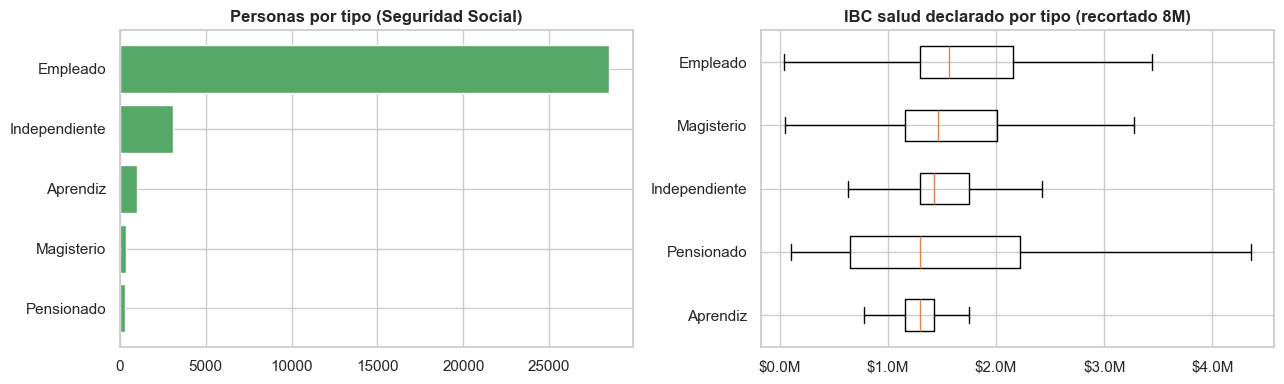

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
d = dist.sort_values()
axes[0].barh(d.index, d.values, color="#55a868")
axes[0].set_title("Personas por tipo (Seguridad Social)")
# Ingreso declarado (IBC) por tipo de persona
ib = ssp[ssp["ibc_ss"] > 0]
orden = ib.groupby("tipo_persona")["ibc_ss"].median().sort_values().index
axes[1].boxplot([ib.loc[ib["tipo_persona"] == t, "ibc_ss"].clip(upper=8e6) for t in orden],
                labels=list(orden), vert=False, showfliers=False)
axes[1].set_title("IBC salud declarado por tipo (recortado 8M)")
axes[1].xaxis.set_major_formatter(milM)
plt.tight_layout(); plt.show()

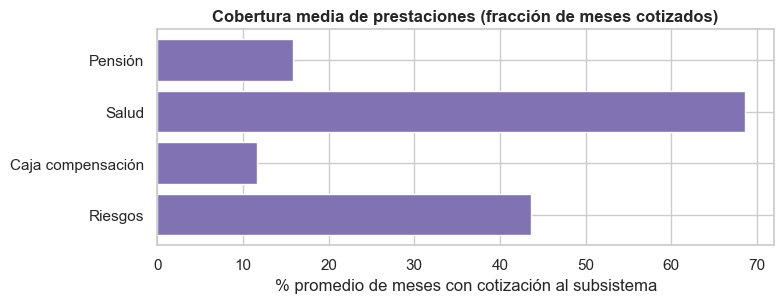

Lectura: la mayoría cotiza salud pero MUCHOS menos cotizan pensión → señal de informalidad/independencia.


In [9]:
# Cobertura de prestaciones por subsistema
cobertura = ssp[["frac_pension", "frac_salud", "frac_caja", "frac_riesgos"]].mean() * 100
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(["Pensión", "Salud", "Caja compensación", "Riesgos"][::-1], cobertura.values[::-1], color="#8172b3")
ax.set_title("Cobertura media de prestaciones (fracción de meses cotizados)")
ax.set_xlabel("% promedio de meses con cotización al subsistema")
plt.tight_layout(); plt.show()
print("Lectura: la mayoría cotiza salud pero MUCHOS menos cotizan pensión → señal de informalidad/independencia.")

### 4.2 · Transferencias — flujos reales (sin cuenta propia)

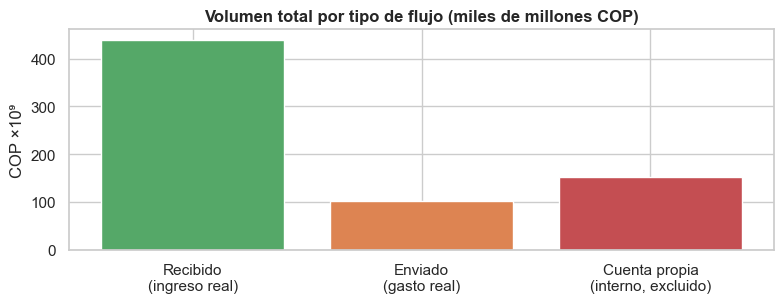

Cuenta propia excluida del ingreso: $151.8B (22% del volumen movido)


In [10]:
pm_trf = ap.build_person_month("trf", solo_ventana_comun=True)
tot = pm_trf[["recibido", "enviado", "cuenta_propia_total"]].sum() / 1e9
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(["Recibido\n(ingreso real)", "Enviado\n(gasto real)", "Cuenta propia\n(interno, excluido)"],
       tot.values, color=["#55a868", "#dd8452", "#c44e52"])
ax.set_title("Volumen total por tipo de flujo (miles de millones COP)")
ax.set_ylabel("COP ×10⁹")
plt.tight_layout(); plt.show()
print(f"Cuenta propia excluida del ingreso: ${tot['cuenta_propia_total']:.1f}B "
      f"({tot['cuenta_propia_total']/tot.sum()*100:.0f}% del volumen movido)")

### 4.3 · PSE — consumo por categoría y banco autorizador
La categoría de comercio (taxonomía por palabras clave) y la `Entidad autorizadora` decodificada por prefijo.

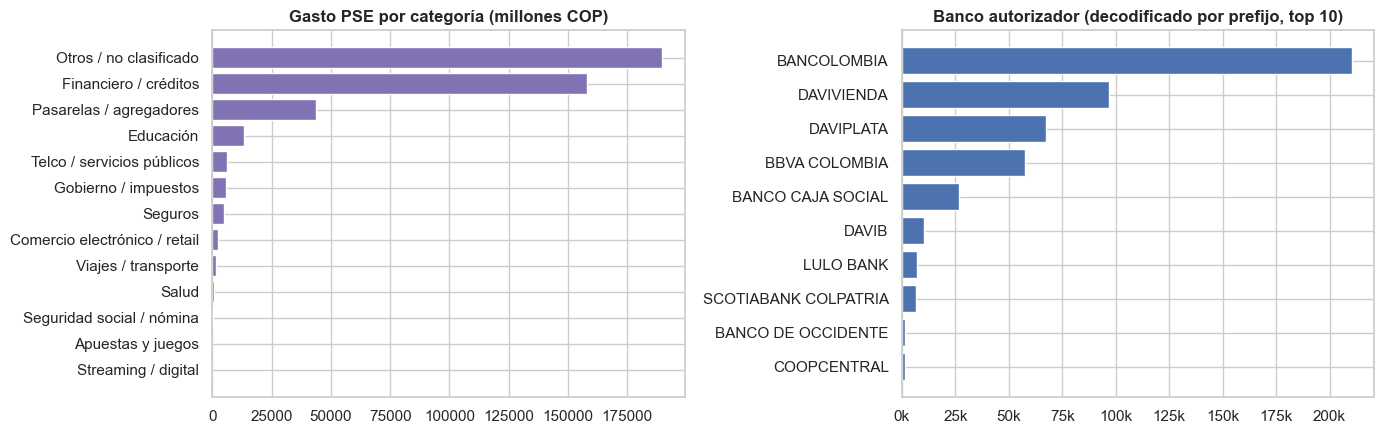

Entidad recuperable (alta+media confianza): 45.8%


In [11]:
pse_raw = ap.load_raw("pse")
cat = ap.categorize_comercio(pse_raw["Comercio"]); val = ap.num(pse_raw["Valor"])
resumen = (pd.DataFrame({"cat": cat, "val": val}).groupby("cat")["val"].sum()
           .sort_values() / 1e6)
ent = ap.decode_entidad_autorizadora(pse_raw["Entidad autorizadora"])
banco = ent[~ent["entidad"].isin(["DESCONOCIDO", "AMBIGUO"])]["entidad"].value_counts().head(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(resumen.index, resumen.values, color="#8172b3")
axes[0].set_title("Gasto PSE por categoría (millones COP)")
axes[1].barh(banco.index, banco.values, color="#4c72b0")
axes[1].set_title("Banco autorizador (decodificado por prefijo, top 10)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f}k"))
plt.tight_layout(); plt.show()
print(f"Entidad recuperable (alta+media confianza): {ent['entidad_confianza'].isin(['alta','media']).mean()*100:.1f}%")

## 5 · Materialización

Se guardan las tablas persona×mes (con `recibido/enviado` ya sin cuenta propia) y el perfil de personas de
Seguridad Social, que consumen los notebooks de modelado.

In [12]:
shapes = ap.materialize()
ssp.to_parquet(ROOT / "Data" / "processed" / "person_ss_profile.parquet", index=False)
print("Materializado en Data/processed/:")
for f, s in shapes.items():
    print(f"  person_month_{f:3}: {s[0]:>9,} filas x {s[1]:>2} cols")
print(f"  person_ss_profile : {len(ssp):>9,} filas x {ssp.shape[1]:>2} cols")

Materializado en Data/processed/:
  person_month_ss :   663,012 filas x  6 cols
  person_month_trf:   268,843 filas x  9 cols
  person_month_pse:   339,619 filas x 18 cols
  person_ss_profile :    33,281 filas x 11 cols


## 6 · Cierre

- **Llave = cédula** → las 3 fuentes cruzan (riesgo de colisión asumido y documentado).
- **Cuenta propia excluida** del ingreso/gasto real; **duplicados exactos** eliminados.
- **Clasificación de personas SS** (empleado / independiente / pensionado / aprendiz…) + cobertura de
  prestaciones e ingreso → insumo del modelo de **ciclo de vida** y enriquecimiento del de **valor**.
- Ambos modelos parten ahora de las 3 fuentes cruzadas.

**Limitación viva:** truncamiento de Transferencias/PSE en el tope de Excel (volúmenes de la cola
subestimados) y ausencia de campo de ciudad (sin capa geográfica).